# Actividad práctica: comparación de métodos de escalamiento en Scikit-learn

## Objetivo
En este notebook replico el tutorial oficial de Scikit-learn sobre la comparación de distintos métodos de escalamiento cuando existen valores atípicos (outliers), usando el dataset California Housing.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    Normalizer
)

In [3]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
feature_names = X.columns.tolist()

features = ["MedInc", "AveOccup"]

X_plot = X[features].copy()

X_plot.head()

,MedInc,AveOccup
0,8.3252,2.555556
1,8.3014,2.109842
2,7.2574,2.802260
3,5.6431,2.547945
4,3.8462,2.181467


## Selección de variables

En este ejemplo uso las variables **MedInc** (ingreso medio) y **AveOccup** (ocupación promedio por vivienda), porque en el tutorial oficial se eligen justamente esas dos para mostrar cómo afectan los valores atípicos al escalamiento.

La variable de ingreso medio tiene una distribución con cola larga, mientras que la ocupación promedio tiene algunos valores atípicos muy grandes. Eso permite ver claramente cómo responde cada scaler.

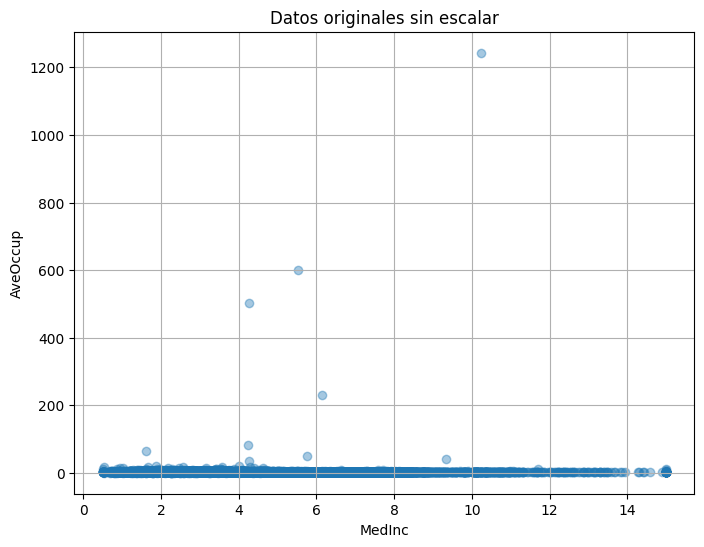

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X_plot["MedInc"], X_plot["AveOccup"], alpha=0.4)
plt.xlabel("MedInc")
plt.ylabel("AveOccup")
plt.title("Datos originales sin escalar")
plt.grid(True)
plt.show()

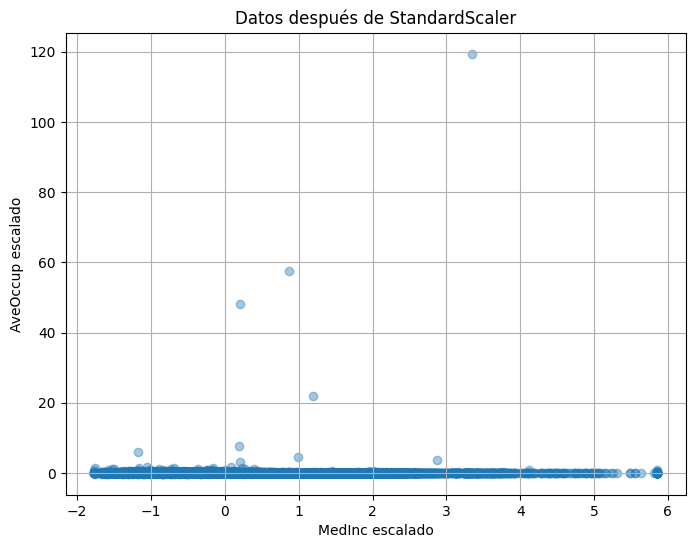

In [5]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X_plot)

X_standard_df = X_plot.copy()
X_standard_df["MedInc"] = X_standard[:, 0]
X_standard_df["AveOccup"] = X_standard[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_standard_df["MedInc"], X_standard_df["AveOccup"], alpha=0.4)
plt.xlabel("MedInc escalado")
plt.ylabel("AveOccup escalado")
plt.title("Datos después de StandardScaler")
plt.grid(True)
plt.show()

## StandardScaler

### ¿Qué hace matemáticamente?
Este transformador toma cada variable, le resta su media y luego divide el resultado por su desviación estándar. Así, los datos quedan centrados alrededor de 0 y con una escala comparable.

### ¿Cómo trata los valores atípicos?
No los trata de forma especial. Como usa la media y la desviación estándar, los valores atípicos influyen bastante en el cálculo. Por eso, si hay outliers muy grandes, pueden terminar “apretando” a la mayoría de los datos en una zona chica del gráfico.

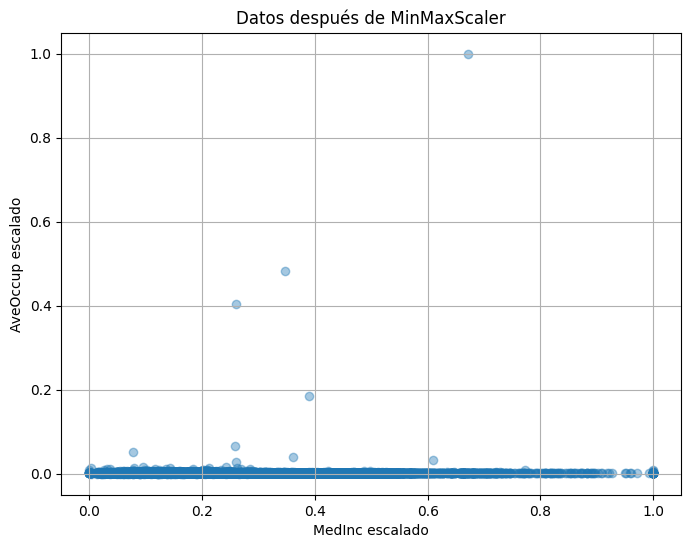

In [5]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X_plot)

X_minmax_df = X_plot.copy()
X_minmax_df["MedInc"] = X_minmax[:, 0]
X_minmax_df["AveOccup"] = X_minmax[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_minmax_df["MedInc"], X_minmax_df["AveOccup"], alpha=0.4)
plt.xlabel("MedInc escalado")
plt.ylabel("AveOccup escalado")
plt.title("Datos después de MinMaxScaler")
plt.grid(True)
plt.show()

## MinMaxScaler

### ¿Qué hace matemáticamente?
Este transformador escala los datos a un rango fijo, generalmente entre 0 y 1. Para hacerlo, toma el valor mínimo y máximo de cada variable y ajusta todos los datos dentro de ese rango.

### ¿Cómo trata los valores atípicos?
Es muy sensible a los outliers. Si hay valores extremos muy grandes o muy chicos, estos determinan el rango completo, haciendo que la mayoría de los datos queden muy concentrados en una zona pequeña del gráfico.

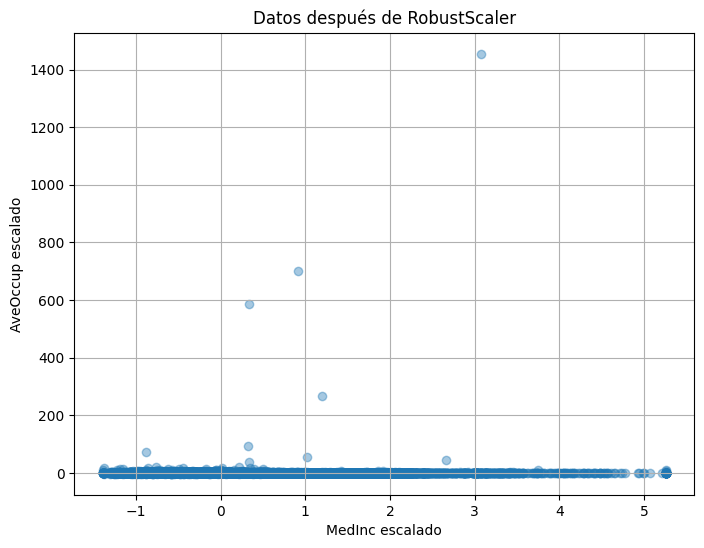

In [6]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X_plot)

X_robust_df = X_plot.copy()
X_robust_df["MedInc"] = X_robust[:, 0]
X_robust_df["AveOccup"] = X_robust[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_robust_df["MedInc"], X_robust_df["AveOccup"], alpha=0.4)
plt.xlabel("MedInc escalado")
plt.ylabel("AveOccup escalado")
plt.title("Datos después de RobustScaler")
plt.grid(True)
plt.show()

## RobustScaler

### ¿Qué hace matemáticamente?
Este transformador utiliza la mediana y el rango intercuartílico (IQR) para escalar los datos. En lugar de usar la media y la desviación estándar, centra los datos en la mediana y los escala según la distancia entre el percentil 25 y el percentil 75.

### ¿Cómo trata los valores atípicos?
Es robusto frente a los outliers, ya que estos no afectan significativamente la mediana ni el rango intercuartílico. Por eso, logra mantener una mejor distribución de la mayoría de los datos sin que queden comprimidos por valores extremos.

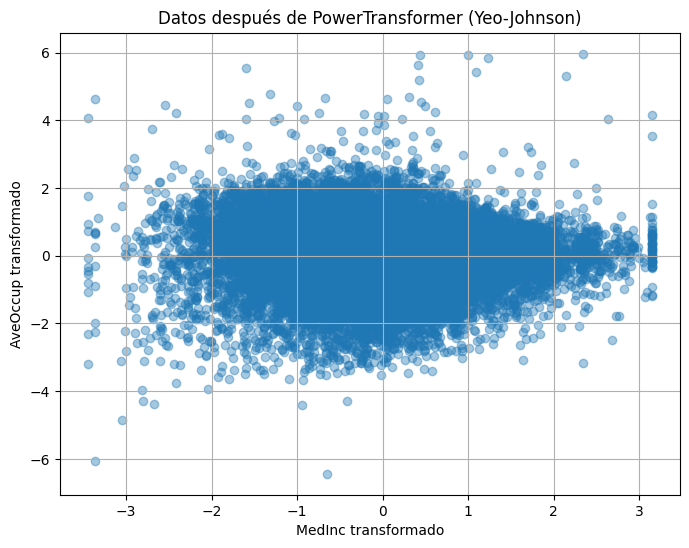

In [7]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(method='yeo-johnson')
X_power = power_transformer.fit_transform(X_plot)

X_power_df = X_plot.copy()
X_power_df["MedInc"] = X_power[:, 0]
X_power_df["AveOccup"] = X_power[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_power_df["MedInc"], X_power_df["AveOccup"], alpha=0.4)
plt.xlabel("MedInc transformado")
plt.ylabel("AveOccup transformado")
plt.title("Datos después de PowerTransformer (Yeo-Johnson)")
plt.grid(True)
plt.show()

## PowerTransformer (Yeo-Johnson)

### ¿Qué hace matemáticamente?
Aplica una transformación no lineal a los datos con el objetivo de que sigan una distribución más cercana a una normal (gaussiana).

### ¿Cómo trata los valores atípicos?
Reduce el impacto de los outliers al comprimir los valores extremos. No los elimina, pero hace que su influencia sea menor al cambiar la forma de la distribución.

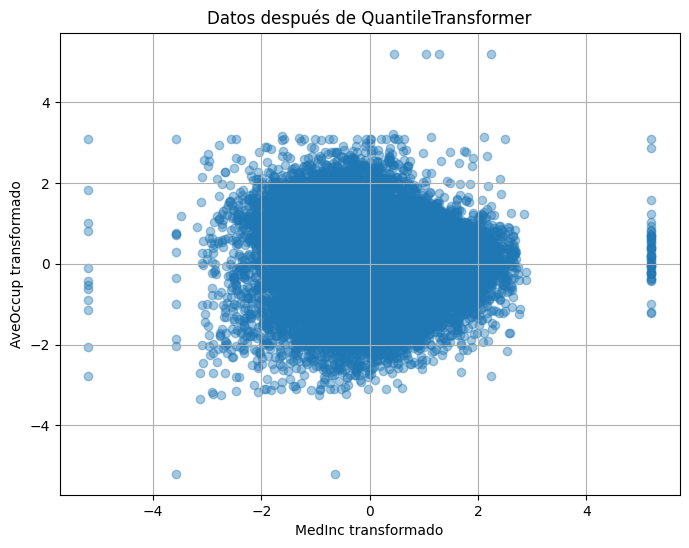

In [8]:
from sklearn.preprocessing import QuantileTransformer

quantile_transformer = QuantileTransformer(output_distribution='normal')
X_quantile = quantile_transformer.fit_transform(X_plot)

X_quantile_df = X_plot.copy()
X_quantile_df["MedInc"] = X_quantile[:, 0]
X_quantile_df["AveOccup"] = X_quantile[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_quantile_df["MedInc"], X_quantile_df["AveOccup"], alpha=0.4)
plt.xlabel("MedInc transformado")
plt.ylabel("AveOccup transformado")
plt.title("Datos después de QuantileTransformer")
plt.grid(True)
plt.show()

## QuantileTransformer

### ¿Qué hace matemáticamente?
Transforma los datos utilizando percentiles, ajustando su distribución para que siga una forma específica, en este caso una distribución normal.

### ¿Cómo trata los valores atípicos?
Reduce mucho el impacto de los outliers, ya que los reubica según su posición relativa (percentil), haciendo que los extremos no dominen la escala.

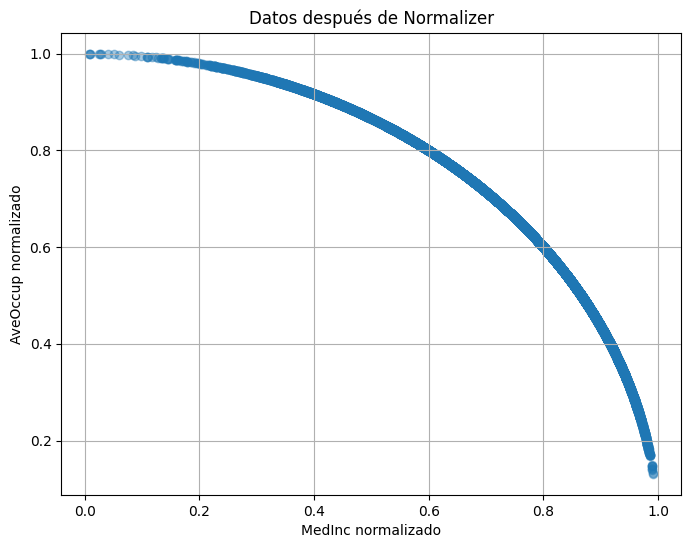

In [9]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X_normalized = normalizer.fit_transform(X_plot)

X_normalized_df = X_plot.copy()
X_normalized_df["MedInc"] = X_normalized[:, 0]
X_normalized_df["AveOccup"] = X_normalized[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_normalized_df["MedInc"], X_normalized_df["AveOccup"], alpha=0.4)
plt.xlabel("MedInc normalizado")
plt.ylabel("AveOccup normalizado")
plt.title("Datos después de Normalizer")
plt.grid(True)
plt.show()

## Normalizer

### ¿Qué hace matemáticamente?
Escala cada fila (muestra) individualmente para que tenga norma igual a 1. Esto significa que no transforma las columnas, sino cada fila completa.

### ¿Cómo trata los valores atípicos?
No está pensado para tratar outliers. Su objetivo es normalizar la magnitud de cada muestra, no la distribución de los datos.

**CUESTIONARIO**

### 1. Sensibilidad a los valores atípicos

Cuando uso StandardScaler y MinMaxScaler, se ve que la masa principal de los datos (el cuadrado denso) queda muy comprimida cuando hay outliers muy alejados.

Esto pasa porque ambos métodos dependen de valores extremos:
- StandardScaler usa la media y la desviación estándar
- MinMaxScaler usa el mínimo y el máximo

Entonces, si hay valores muy grandes o muy chicos, afectan toda la escala y hacen que la mayoría de los datos pierdan detalle.

Por eso, estos escaladores pueden ser problemáticos cuando existen outliers, ya que no representan bien la distribución real de la mayoría de los datos.

### 2. Robustez

El RobustScaler mantiene mejor el "zoom" en la mayoría de los datos en comparación con el StandardScaler.

Esto sucede porque utiliza la mediana y el rango intercuartílico (IQR), en lugar de la media y la desviación estándar.

Como la mediana no se ve tan afectada por valores extremos, el escalado es más estable y permite visualizar correctamente la mayoría de los datos, aunque los outliers sigan existiendo.

### 3. Normalización de la distribución

El PowerTransformer y el QuantileTransformer buscan que los datos sigan una distribución normal, pero lo hacen de formas distintas.

El PowerTransformer aplica una transformación más suave para corregir la forma de la distribución, mientras que el QuantileTransformer reorganiza completamente los datos en base a percentiles.

Visualmente, el QuantileTransformer genera una distribución más uniforme o perfectamente ajustada, mientras que el PowerTransformer mantiene más la estructura original.

Estas transformaciones son especialmente útiles en modelos que asumen normalidad en los datos, como regresión lineal o algunos modelos estadísticos.

### 4. El caso del Normalizer

El Normalizer actúa sobre las filas en lugar de las columnas, lo que significa que transforma cada muestra individualmente para que tenga una longitud (norma) igual a 1.

Por eso, el gráfico toma una forma circular, ya que todos los puntos quedan distribuidos sobre una circunferencia.

Un caso de uso típico es el procesamiento de texto, donde se representan documentos como vectores de palabras. En este caso, interesa comparar la dirección del vector y no su magnitud.

### 5. Conclusión técnica

Si tuviera que entrenar un modelo de regresión lineal y la variable "ingreso medio" tiene muchos valores atípicos, elegiría usar RobustScaler.

Esto se debe a que es menos sensible a los outliers, ya que utiliza la mediana y el rango intercuartílico. De esta forma, permite mantener una mejor representación de la mayoría de los datos sin que los valores extremos distorsionen la escala.